# DATA-445 — Homework Assignment 1

**Instructions**

- This homework assignment is worth 94 points.
- Please submit a `.ipynb` file to Blackboard.
- Please strive for clarity and organization.
- **AI usage**:
  - AI use is strictly **prohibited** for conceptual exercises.
  - For applied (Python) exercises, you may use AI exclusively for **debugging**. Do not use AI to generate answers.
- **Due Date: September 11, 2026, by 11:59 PM.**

## Exercise 1

(4 points) What type of algorithm would you use to segment a company customers database into multiple groups?

i would use unsupervised learning because it works well with real life raw data by sorting the data into groups based off of their shared traits

## Exercise 2

(4 points) Would you frame the problem of spam detection as a supervised learning problem or an unsupervised learning problem? Explain.

in the case of spam detection you would use supervised learning because it trains on the classification of the emails. It becomes stronger the more it learns from itself and the patterns. You can kind of make sense of this in real life applications. The more you mark your spam emails as junk or trash it begins to automatically put these emails in your junk folder. 

## Exercise 3

(4 points) What is a test set, and why would you want to use it?

A test set is the next step taken after a model has been trained, this is an important step because it shows how well your model is working when it is presented with new data. You would want to use a test set as another step in securing the efficiency and effectivenss of your model. The test set also shows a lot of important stats that will be crucial in evaluating your model.

## Exercise 4

(4 points) You are training a classification model with 100 variables/features that achieves 95% accuracy in the training dataset. However, when you run it in the test dataset, you only get 60% accuracy. Which of the following options are valid approached to solve this problem?

- (a) Reduce the number of input variables/features
- (b) Add extra variables/features
- (c) Implement cross-validation during the training process
- (d) Select another algorithm
- (e) (a) and (c)
- (f) (a) and (d)
- (g) (b) and (c)
- (h) (b) and (d)
- (i) None of the above

(f)

## Exercise 5

Consider the `Real_Estate.csv` data file posted on Blackboard (under the In-Class 3f assignment link). This file contains information related to 414 houses. The goal is to predict the house price of unit area. In **Python**, answer the following:

### (a) (3 points)

Using the pandas library, read the csv data file and create a data-frame called `house_price`.

In [ ]:
#Loading the libraries
import pandas as pd

#Loading the dataset
house_price = pd.read_csv("Real_Estate.csv")

#Displaying the first 5 rows of the dataset
house_price.head()

,No,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


### (b) (3 points)

Drop the `No` and `transaction_date` columns.

In [ ]:
#Dropping the columns "No" and "transaction_date"
house_price = house_price.drop(columns=["No", "transaction_date"], axis=1)

#Displaying the new dataframe without the dropped columns
house_price.head()



,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,32.0,84.87882,10,24.98298,121.54024,37.9
1,19.5,306.59470,9,24.98034,121.53951,42.2
2,13.3,561.98450,5,24.98746,121.54391,47.3
3,13.3,561.98450,5,24.98746,121.54391,54.8
4,5.0,390.56840,5,24.97937,121.54245,43.1


### (c) (4 points)

Split the data-frame into two data-frames: train (80%) and test (20%).

In [13]:
x = house_price[["house_age", "distance_to_the_nearest_MRT_station", "number_of_convenience_stores", "latitude", "longitude"]]
y= house_price["house_price_of_unit_area"]

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### (d) (8 points)

Using the `house_price` data-frame, compute the correlation between each input variable and `house_price_of_unit_area`, and display the results as a heatmap. Which two variables are most correlated (in absolute value) with the target variable?

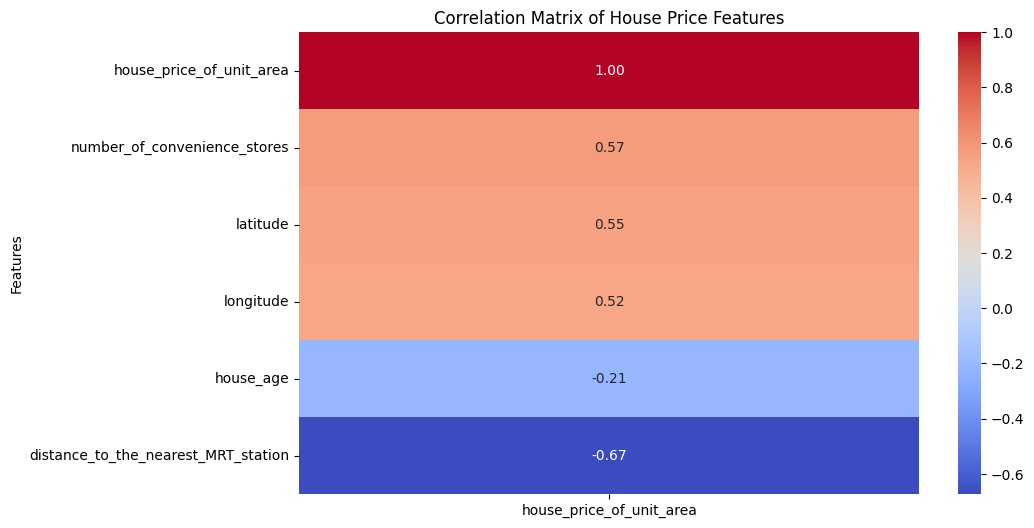

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation = house_price.corr()
correlation_matrix = correlation[["house_price_of_unit_area"]].sort_values(by="house_price_of_unit_area",ascending=False)

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of House Price Features")
plt.ylabel("Features")
plt.show()



### (e) (10 points)

Using the train data-frame, build a linear regression model in which: `house_age`, `distance_to_the_nearest_MRT_station`, `number_of_convenience_stores`, `latitude`, and `longitude` are the input variables, and `house_price_of_unit_area` is the target variable. After the model is built, predict the house price of unit area of the houses in the test data-frame. Report the MSE.

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# defining the impots and target variables 
x = house_price[["house_age", "distance_to_the_nearest_MRT_station", 
                 "number_of_convenience_stores", "latitude", "longitude"]]
y = house_price["house_price_of_unit_area"]

#creating the linear regression model 
model = LinearRegression()
model.fit(x,y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 78.52590240726795


### (f) (10 points)

Using the train data-frame, build a linear regression model in which: `house_age`, `number_of_convenience_stores`, `latitude`, and `longitude` are the input variables, and `house_price_of_unit_area` is the target variable. After the model is built, predict the house price of unit area of the houses in the test data-frame. Report the MSE.

In [25]:
from sklearn.linear_model import LinearRegression

# defining the impots and target variables 
x = house_price[["house_age","number_of_convenience_stores", "latitude", "longitude"]]
y = house_price["house_price_of_unit_area"]

#creating the linear regression model 
model = LinearRegression()
model.fit(x,y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### (g) (5 points)

Using the results from parts (d) and (e), what model would you use? Explain.

i think the correlation matrix gives a good visual on which variables are most correlated with the target variable however the mse tells us how close the predictions are to the actual data and is a lot more precise and reliable

### (h) (15 points)

Repeat steps (c) to (e) 100 times, and visualize the MSE of each of the models at each iteration. Which of the two model has better performance on the test datasets? Explain.

In [31]:
msemodel_e = []
msemodel_f = []

for j in range(100):
    x_train, x_test, y_train, y_test = train_test_split(house_price[["house_age", "distance_to_the_nearest_MRT_station", "number_of_convenience_stores", "latitude", "longitude"]], house_price["house_price_of_unit_area"], test_size=0.2, random_state=j)

#model e
    x_train_e = house_price[["house_age", "distance_to_the_nearest_MRT_station", "number_of_convenience_stores", "latitude", "longitude"]]

    y_train_e = house_price["house_price_of_unit_area"]

    x_test_e = house_price[["house_age", "distance_to_the_nearest_MRT_station", "number_of_convenience_stores", "latitude", "longitude"]]
y_test_e = house_price["house_price_of_unit_area"]

model_e = LinearRegression()
model_e.fit(x_train_e, y_train_e)

y_pred_e = model_e.predict(x_test_e)

mse_e = mean_squared_error(y_test_e, y_pred_e)
msemodel_e.append(mse_e)

x_train_f = house_price[["house_age","number_of_convenience_stores", "latitude", "longitude"]]
y_train_f = house_price["house_price_of_unit_area"]
x_test_f = house_price[["house_age","number_of_convenience_stores", "latitude", "longitude"]]
y_test_f = house_price["house_price_of_unit_area"]

model_f = LinearRegression()
model_f.fit(x_train_f, y_train_f)

y_pred_f = model_f.predict(x_test_f)

mse_f = mean_squared_error(y_test_f, y_pred_f)
msemodel_f.append(mse_f)

print('avg MSE for model e:', round(sum(msemodel_e)/100, 3))
print('avg MSE for model f:', round(sum(msemodel_f)/100, 3))
    

avg MSE for model e: 0.792
avg MSE for model f: 0.859


### (i) (8 points) 
Using scikit-learn's `cross_val_score`, perform 10-fold cross-validation on the full model from Exercise 5, part (d) (using the entire `house_price` data-frame). Report the average MSE across the 10 folds.

## Exercise 6

(6 points) Explain the bias-variance tradeoff, and describe how it relates to a model's ability to generalize to new/unseen data.

the tradeoff is balancing between a high bias or high variance to generalize new data you have to find a good balance between these two. When it comes to new data the model needs to find a good balance so it can know the actual patterns and not just learning the noise from the training.

## Exercise 7

(6 points) The "curse of dimensionality" refers to the difficulties that arise when working with data that has a very large number of features. Explain why having too many features can hurt the performance of a machine learning model, and describe one strategy to mitigate this problem.

having too many features can hurt the performance of a machine learning model beacuse there are certain models such as KNN that performs poorly with a lot of features. Since KNN needs distance to work well, overloading this feature will cause the algorithm to be unable to find proper groupings. one way you could mitigate this issue is to remove repetitive features or unecessary feature. You could also perform a feature selection.